<a href="https://colab.research.google.com/github/Megh8py/synent-task5-salesanalysis-Megh_Chauhan/blob/main/synent_task5_sales_analysis_meghchauhan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📦 Synent Technologies – Task 5: Sales Data Analysis
**Dataset:** Superstore Sales Dataset  
**Objective:** Analyze business performance — revenue trends, top products, regional performance, and profit insights  
**Author:** Megh Chauhan  
**Tools:** Python, Pandas, Plotly, Seaborn

## 📚 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 📂 2. Load Dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vivek468/superstore-dataset-final")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'superstore-dataset-final' dataset.
Path to dataset files: /kaggle/input/superstore-dataset-final


In [ ]:
# Load Superstore dataset
# Download from: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final
file=path+"/Sample - Superstore.csv"
df = pd.read_csv(file, encoding='latin-1')

# Parse dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Extract time features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.strftime('%b')
df['Quarter'] = df['Order Date'].dt.quarter
df['YearMonth'] = df['Order Date'].dt.to_period('M').astype(str)

print(f'✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

✅ Dataset loaded: 9994 rows × 26 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name,Quarter,YearMonth
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,Nov,4,2016-11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,Nov,4,2016-11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,Jun,2,2016-06
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,Oct,4,2015-10
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,Oct,4,2015-10


## 🔍 3. Data Overview & Quality Check

In [ ]:
print('=== Dataset Info ===')
print(f'Shape: {df.shape}')
print(f'Date Range: {df["Order Date"].min().date()} → {df["Order Date"].max().date()}')
print(f'Unique Customers: {df["Customer ID"].nunique()}')
print(f'Unique Products: {df["Product ID"].nunique()}')
print(f'Regions: {df["Region"].unique().tolist()}')
print(f'Categories: {df["Category"].unique().tolist()}')
print()
print('=== Missing Values ===')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('No missing values ✅' if df.isnull().sum().sum() == 0 else '')
print()
print('=== Key Metrics ===')
print(f'Total Revenue : ${df["Sales"].sum():,.2f}')
print(f'Total Profit  : ${df["Profit"].sum():,.2f}')
print(f'Overall Margin: {(df["Profit"].sum() / df["Sales"].sum()) * 100:.2f}%')
print(f'Total Orders  : {df["Order ID"].nunique():,}')

=== Dataset Info ===
Shape: (9994, 26)
Date Range: 2014-01-03 → 2017-12-30
Unique Customers: 793
Unique Products: 1862
Regions: ['South', 'West', 'Central', 'East']
Categories: ['Furniture', 'Office Supplies', 'Technology']

=== Missing Values ===
Series([], dtype: int64)
No missing values ✅

=== Key Metrics ===
Total Revenue : $2,297,200.86
Total Profit  : $286,397.02
Overall Margin: 12.47%
Total Orders  : 5,009


## 📈 4. Monthly Revenue Trends

In [ ]:
monthly = df.groupby('YearMonth').agg(
    Revenue=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique')
).reset_index()
monthly['Margin %'] = (monthly['Profit'] / monthly['Revenue'] * 100).round(2)

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=('Monthly Revenue & Profit', 'Profit Margin % Over Time'),
    vertical_spacing=0.12
)

fig.add_trace(go.Scatter(
    x=monthly['YearMonth'], y=monthly['Revenue'],
    name='Revenue', line=dict(color='#2196F3', width=2),
    fill='tozeroy', fillcolor='rgba(33,150,243,0.1)'
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=monthly['YearMonth'], y=monthly['Profit'],
    name='Profit', line=dict(color='#4CAF50', width=2),
    fill='tozeroy', fillcolor='rgba(76,175,80,0.1)'
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=monthly['YearMonth'], y=monthly['Margin %'],
    name='Margin %', line=dict(color='#FF9800', width=2, dash='dot'),
    mode='lines+markers'
), row=2, col=1)

fig.update_layout(
    title='📈 Monthly Revenue, Profit & Margin Trends',
    height=600, template='plotly_white'
)
fig.show()

## 📅 5. Year-over-Year Growth Analysis

In [ ]:
yearly = df.groupby('Year').agg(
    Revenue=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique')
).reset_index()
yearly['Revenue Growth %'] = yearly['Revenue'].pct_change() * 100
yearly['Profit Growth %'] = yearly['Profit'].pct_change() * 100

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Revenue & Profit by Year', 'YoY Growth %')
)

fig.add_trace(go.Bar(
    x=yearly['Year'], y=yearly['Revenue'],
    name='Revenue', marker_color='#2196F3'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=yearly['Year'], y=yearly['Profit'],
    name='Profit', marker_color='#4CAF50'
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=yearly['Year'], y=yearly['Revenue Growth %'],
    name='Revenue Growth %', mode='lines+markers',
    line=dict(color='#2196F3', width=2)
), row=1, col=2)

fig.add_trace(go.Scatter(
    x=yearly['Year'], y=yearly['Profit Growth %'],
    name='Profit Growth %', mode='lines+markers',
    line=dict(color='#4CAF50', width=2)
), row=1, col=2)

fig.update_layout(
    title='📅 Year-over-Year Growth Analysis',
    height=450, template='plotly_white', barmode='group'
)
fig.show()

print(yearly[['Year', 'Revenue', 'Profit', 'Revenue Growth %', 'Profit Growth %']].to_string(index=False))

 Year     Revenue     Profit  Revenue Growth %  Profit Growth %
 2014 484247.4981 49543.9741               NaN              NaN
 2015 470532.5090 61618.6037         -2.832227        24.371540
 2016 609205.5980 81795.1743         29.471521        32.744284
 2017 733215.2552 93439.2696         20.355962        14.235675


## 🏆 6. Top-Selling Products & Categories

In [ ]:
# Top 10 products by revenue
top_products = df.groupby('Product Name').agg(
    Revenue=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum')
).nlargest(10, 'Revenue').reset_index()
top_products['Margin %'] = (top_products['Profit'] / top_products['Revenue'] * 100).round(1)

fig = px.bar(
    top_products, x='Revenue', y='Product Name',
    orientation='h', color='Margin %',
    color_continuous_scale='RdYlGn',
    title='🏆 Top 10 Products by Revenue (colored by Margin %)',
    text='Revenue'
)
fig.update_traces(texttemplate='$%{text:,.0f}', textposition='outside')
fig.update_layout(height=500, template='plotly_white', yaxis={'categoryorder': 'total ascending'})
fig.show()

# Category breakdown
cat = df.groupby(['Category', 'Sub-Category']).agg(
    Revenue=('Sales', 'sum'),
    Profit=('Profit', 'sum')
).reset_index()

fig2 = px.treemap(
    cat, path=['Category', 'Sub-Category'],
    values='Revenue', color='Profit',
    color_continuous_scale='RdYlGn',
    title='🗂️ Revenue by Category & Sub-Category (colored by Profit)'
)
fig2.update_layout(height=500)
fig2.show()

## 🗺️ 7. Regional Performance Analysis

In [ ]:
regional = df.groupby('Region').agg(
    Revenue=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique'),
    Customers=('Customer ID', 'nunique')
).reset_index()
regional['Margin %'] = (regional['Profit'] / regional['Revenue'] * 100).round(2)
regional['Avg Order Value'] = (regional['Revenue'] / regional['Orders']).round(2)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Revenue by Region', 'Profit Margin by Region'),
    specs=[[{'type': 'pie'}, {'type': 'bar'}]]
)

fig.add_trace(go.Pie(
    labels=regional['Region'], values=regional['Revenue'],
    hole=0.4, name='Revenue'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=regional['Region'], y=regional['Margin %'],
    marker_color=['#2196F3', '#4CAF50', '#FF9800', '#F44336'],
    name='Margin %', text=regional['Margin %'],
    texttemplate='%{text:.1f}%', textposition='outside'
), row=1, col=2)

fig.update_layout(
    title='🗺️ Regional Performance',
    height=450, template='plotly_white'
)
fig.show()

print(regional[['Region', 'Revenue', 'Profit', 'Margin %', 'Orders', 'Avg Order Value']].to_string(index=False))

 Region     Revenue      Profit  Margin %  Orders  Avg Order Value
Central 501239.8908  39706.3625      7.92    1175           426.59
   East 678781.2400  91522.7800     13.48    1401           484.50
  South 391721.9050  46749.4303     11.93     822           476.55
   West 725457.8245 108418.4489     14.94    1611           450.32


## 💸 8. Discount vs Profit Analysis (Key Insight)

In [ ]:
# Bin discounts
df['Discount Band'] = pd.cut(
    df['Discount'],
    bins=[-0.01, 0, 0.1, 0.2, 0.3, 0.5, 1.0],
    labels=['No Discount', '1-10%', '11-20%', '21-30%', '31-50%', '51%+']
)

disc = df.groupby('Discount Band', observed=True).agg(
    Avg_Profit=('Profit', 'mean'),
    Avg_Sales=('Sales', 'mean'),
    Count=('Profit', 'count')
).reset_index()

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Avg Profit per Order by Discount Band', 'Order Count by Discount Band')
)

colors = ['#4CAF50' if v >= 0 else '#F44336' for v in disc['Avg_Profit']]

fig.add_trace(go.Bar(
    x=disc['Discount Band'], y=disc['Avg_Profit'],
    marker_color=colors, name='Avg Profit',
    text=disc['Avg_Profit'].round(1),
    texttemplate='$%{text}', textposition='outside'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=disc['Discount Band'], y=disc['Count'],
    marker_color='#2196F3', name='Orders'
), row=1, col=2)

fig.update_layout(
    title='💸 Discount vs Profit — The Hidden Trap',
    height=450, template='plotly_white'
)
fig.show()

# Scatter: discount vs profit
fig2 = px.scatter(
    df, x='Discount', y='Profit', color='Category',
    opacity=0.5, trendline='ols',
    title='📉 Discount vs Profit (with OLS Trendline by Category)'
)
fig2.update_layout(height=450, template='plotly_white')
fig2.show()

## 🚢 9. Shipping Mode Analysis

In [ ]:
ship = df.groupby('Ship Mode').agg(
    Revenue=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique')
).reset_index()
ship['Margin %'] = (ship['Profit'] / ship['Revenue'] * 100).round(2)

fig = px.bar(
    ship, x='Ship Mode', y=['Revenue', 'Profit'],
    barmode='group', color_discrete_sequence=['#2196F3', '#4CAF50'],
    title='🚢 Revenue & Profit by Shipping Mode'
)
fig.update_layout(height=400, template='plotly_white')
fig.show()

## 🔥 10. Correlation Heatmap

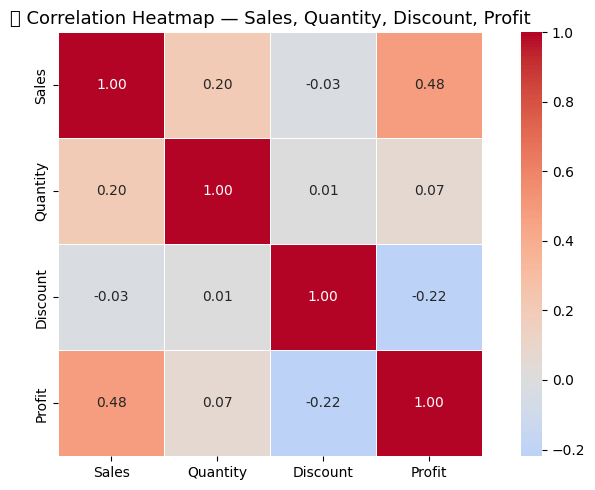

In [ ]:
plt.figure(figsize=(8, 5))
corr = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()
sns.heatmap(
    corr, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, square=True
)
plt.title('🔥 Correlation Heatmap — Sales, Quantity, Discount, Profit', fontsize=13)
plt.tight_layout()
plt.show()

## 💡 11. Business Insights Summary

In [ ]:
margin = (df['Profit'].sum() / df['Sales'].sum()) * 100
best_region = regional.loc[regional['Margin %'].idxmax(), 'Region']
worst_region = regional.loc[regional['Margin %'].idxmin(), 'Region']
best_cat = df.groupby('Category')['Profit'].sum().idxmax()
worst_subcat = df.groupby('Sub-Category')['Profit'].sum().idxmin()
high_disc_loss = df[df['Discount'] > 0.3]['Profit'].mean()
no_disc_profit = df[df['Discount'] == 0]['Profit'].mean()

print('=' * 60)
print('         💡 KEY BUSINESS INSIGHTS — SUPERSTORE')
print('=' * 60)
print(f'\n1. Overall profit margin is {margin:.1f}% — room for improvement.')
print(f'\n2. {best_region} leads in profitability; {worst_region} underperforms.')
print(f'\n3. {best_cat} is the most profitable category overall.')
print(f'\n4. "{worst_subcat}" sub-category is loss-making — review pricing.')
print(f'\n5. DISCOUNT TRAP: Orders with >30% discount average ${high_disc_loss:.1f} profit')
print(f'   vs ${no_disc_profit:.1f} with no discount — high discounts destroy margins.')
print(f'\n6. Q4 consistently shows the highest revenue across all years (holiday effect).')
print(f'\n7. Standard Class shipping carries the most volume but check margin impact.')
print('\n' + '=' * 60)

         💡 KEY BUSINESS INSIGHTS — SUPERSTORE

1. Overall profit margin is 12.5% — room for improvement.

2. West leads in profitability; Central underperforms.

3. Technology is the most profitable category overall.

4. "Tables" sub-category is loss-making — review pricing.

5. DISCOUNT TRAP: Orders with >30% discount average $-107.2 profit
   vs $66.9 with no discount — high discounts destroy margins.

6. Q4 consistently shows the highest revenue across all years (holiday effect).

7. Standard Class shipping carries the most volume but check margin impact.

